In [1]:
#Here each molecule is considered as a node. So here there is only one graph.

In [1]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import networkx as nx

In [2]:
import matplotlib.pyplot as plt

In [3]:
df1 = pd.read_csv('./ido1_tdo_common_1126.csv', na_values=['na'])
df1 = df1.dropna(ignore_index=True)
df1

,molecule_chembl_id,smiles,ido1_ic50,tdo_ic50
0,CHEMBL1909734,Clc1ccccc1-c1cnn[nH]1,86000.0,100000.0
1,CHEMBL2147992,CCc1cccc(-c2c[nH]nn2)c1,13000.0,100000.0
2,CHEMBL2148074,Oc1ccc(Cl)cc1-c1c[nH]nn1,330.0,100000.0
3,CHEMBL4287290,N#Cc1nccc2c(Nc3ccc(F)c(Cl)c3)c(N)oc12,200.0,500.0
4,CHEMBL4282281,Nc1oc2c(-c3ccncc3)nc(F)cc2c1Nc1ccc(F)c(Cl)c1,200.0,500.0
...,...,...,...,...
1121,CHEMBL5974732,Cc1sc2cncn2c1C(O)CC1CCCC1,190.0,573.0
1122,CHEMBL5750760,CC[C@H](C)c1sc2cncn2c1C(O)C1CCCCC1,172.0,962.0
1123,CHEMBL5427485,CN1CCN(CCc2ccc3nc4n(c(=O)c3c2)C2C=CC(F)=CC2C4=...,20.0,90.0
1124,CHEMBL5798663,O=C(CC1c2ccccc2-n2cncc21)C1CCCCC1,550.0,100.0


In [4]:
df2 = df1.loc[:, ['ido1_ic50', 'tdo_ic50']]
df2

,ido1_ic50,tdo_ic50
0,86000.0,100000.0
1,13000.0,100000.0
2,330.0,100000.0
3,200.0,500.0
4,200.0,500.0
...,...,...
1121,190.0,573.0
1122,172.0,962.0
1123,20.0,90.0
1124,550.0,100.0


In [5]:
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] <= 1000:
        df2.loc[i, ['ido1_ic50']] = 1
    else: 
        df2.loc[i, ['ido1_ic50']] = 0

In [6]:
for i in range(len(df2)):
    if df2['tdo_ic50'].values[i] <= 1000:
        df2.loc[i, ['tdo_ic50']] = 1
    else: 
        df2.loc[i, ['tdo_ic50']] = 0

In [7]:
newcol = []
for i in range(len(df2)):
    if df2['ido1_ic50'].values[i] == 1.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('AA')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 0.0:
        newcol.append('II')
    elif df2['ido1_ic50'].values[i] == 0.0 and df2['tdo_ic50'].values[i] == 1.0:
        newcol.append('IA')
    else:
        newcol.append('AI')

In [8]:
target = pd.DataFrame(data=newcol, columns=['ido_tdo'])
target

,ido_tdo
0,II
1,II
2,AI
3,AA
4,AA
...,...
1121,AA
1122,AA
1123,AA
1124,AA


In [9]:
y = target.values.reshape(len(df2),)
y.shape

(1126,)

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [11]:
y_label = encoder.fit_transform(y)

In [12]:
y_label

array([3, 3, 1, ..., 0, 0, 3])

In [13]:
from rdkit.Chem import SaltRemover as sr
remover = sr.SaltRemover()

In [14]:
mols = []
for i in range(len(df1)):
    try:
        mol_i = Chem.MolFromSmiles(df1['smiles'][i])
        if mol_i is None:
            print(f"[WARNING] Invalid SMILES at index {i}, skipping.")
            mols.append(None)  # Maintain indexing for multiprocessing
            continue
        mol_i = remover.StripMol(mol_i, dontRemoveEverything=True)
        mols.append(mol_i)
    except Exception as e:
        print(e)
len(mols)

1126

In [15]:
smiles_list = [df1['smiles'][i] for i in range(len(df1['smiles']))]

In [16]:
names_list = [df1['molecule_chembl_id'][i] for i in range(len(df1['molecule_chembl_id']))]

In [ ]:
#Deprecated method!
FPs = [AllChem.GetMorganFingerprintAsBitVect(mols[i], radius=3, nBits=1024) for i in range(len(mols))]

In [18]:
similarity_matrix = np.zeros((len(FPs), len(FPs)))

In [19]:
similarity_matrix.shape

(1126, 1126)

In [20]:
#only works for bit vectors or sparse count vectors, not arbitrary numerical vectors.
DataStructs.TanimotoSimilarity(FPs[10], FPs[10])

1.0

In [21]:
#Calculate the diagonal elements
for i in range(len(FPs)):
    for j in range(i, len(FPs)):  # Avoid duplicate calculations
        similarity = DataStructs.TanimotoSimilarity(FPs[i], FPs[j])
        similarity_matrix[i, j] = similarity
        similarity_matrix[j, i] = similarity

In [22]:
similarity_matrix.shape

(1126, 1126)

In [23]:
import seaborn as sns

In [24]:
similarity_matrix.min(), similarity_matrix.max(), similarity_matrix.mean()

(0.017241379310344827, 1.0, 0.12398849920188615)

In [25]:
#Step 1: Compute Morgan fingerprints

In [26]:
# Suppose you have a list of SMILES strings for your molecules
def morgan_fp(smiles, radius=2, nBits=1024):
    mol = Chem.MolFromSmiles(smiles)
    fpgen = AllChem.GetMorganGenerator(fpSize=1024)
    arr_fp = fpgen.GetFingerprintAsNumPy(mol)
    return arr_fp

node_features = np.array([morgan_fp(s) for s in smiles_list])  # shape (1126, 1024)
y_label = np.array(y_label)
num_nodes = node_features.shape[0]

In [27]:
node_features.shape

(1126, 1024)

In [28]:
import numpy as np
import torch
import networkx as nx
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from torch_geometric.data import Data
from torch_geometric.utils import subgraph

In [29]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [30]:
y_label

array([3, 3, 1, ..., 0, 0, 3])

In [31]:
y

array(['II', 'II', 'AI', ..., 'AA', 'AA', 'II'], dtype=object)

In [32]:
df1.index.to_numpy()

array([   0,    1,    2, ..., 1123, 1124, 1125])

In [33]:
# Random & Stratify split
from sklearn.model_selection import train_test_split

def stratified_split_indices(indices, y_label, train_ratio=0.6, val_ratio=0.2, seed=42):
    """
    Stratified split of labeled_indices into train/val/test, stratified by y_label.
    Returns train_idx, val_idx, test_idx (subsets of labeled_indices).
    """
    labeled_indices = np.asarray(indices)
    y_label = np.asarray(y_label)

    test_ratio = 1.0 - train_ratio - val_ratio

    # First split: train vs (val+test)
    train_idx, temp_idx, train_y, temp_y = train_test_split(
        labeled_indices,
        y_label,
        train_size=train_ratio,
        stratify=y_label,
        random_state=seed
    )

    # Second split: val vs test (relative proportions within temp)
    val_size_relative = val_ratio / (val_ratio + test_ratio)
    val_idx, test_idx, val_y, test_y = train_test_split(
        temp_idx,
        temp_y,
        train_size=val_size_relative,
        stratify=temp_y,
        random_state=seed
    )

    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = stratified_split_indices(
    df1.index.to_numpy(),
    y_label,
    train_ratio=0.6,
    val_ratio=0.2,
    seed=42
)

print("Train size:", len(train_idx))
print("Val size:", len(val_idx))
print("Test size:", len(test_idx))

Train size: 675
Val size: 225
Test size: 226


In [34]:
svd = TruncatedSVD(n_components=256, random_state=42)
X = svd.fit_transform(node_features)

In [35]:
X.shape

(1126, 256)

In [36]:
#Mutual k-NN graph (with normalized squared weights)
k = 15
max_w = np.max(similarity_matrix ** 2)

edges = set()
for i in range(num_nodes):
    sims = similarity_matrix[i]
    nn_idx = np.argsort(sims)[::-1][1:k+1]
    for j in nn_idx:
        edges.add((i, j))

G = nx.Graph()
#G.add_nodes_from(range(num_nodes))  # keep isolated nodes

for i, j in edges:
    if (j, i) in edges:
        w = (similarity_matrix[i, j] ** 2) / max_w
        G.add_edge(i, j, weight=w)


In [37]:
G.number_of_nodes(), G.number_of_edges()

(1110, 5360)

In [38]:
#Convert to PyG Data object
edge_index = []
edge_attr = []

for u, v, data in G.edges(data=True):
    edge_index.append([u, v])
    edge_index.append([v, u])
    edge_attr.append([data["weight"]])
    edge_attr.append([data["weight"]])

edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attr, dtype=torch.float)

x = torch.tensor(X, dtype=torch.float)
y = torch.tensor(y_label, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
data.num_classes = len(np.unique(y_label))


In [39]:
data

Data(x=[1126, 256], edge_index=[2, 10720], edge_attr=[10720, 1], y=[1126], num_classes=4)

In [40]:
#Create inductive subgraphs
#Training graph (only training nodes)
from torch_geometric.utils import subgraph

device = data.edge_index.device
train_idx = torch.as_tensor(train_idx).to(device)


train_edge_index, train_edge_weight = subgraph(
    train_idx,
    data.edge_index,
    data.edge_attr,
    relabel_nodes=True,
    num_nodes=data.num_nodes
)

train_data = Data(
    x=data.x[train_idx],
    y=data.y[train_idx],
    edge_index=train_edge_index,
    edge_weight=train_edge_weight
)

In [41]:
train_data

Data(x=[675, 256], edge_index=[2, 4130], y=[675], edge_weight=[4130, 1])

In [42]:
data.x[train_idx].shape, data.x[val_idx].shape, data.x[test_idx].shape

(torch.Size([675, 256]), torch.Size([225, 256]), torch.Size([226, 256]))

In [43]:
#Validation graph (train + val nodes)

#Validation is still inductive relative to test nodes:
val_idx = torch.as_tensor(val_idx).to(device)
train_idx = torch.as_tensor(train_idx).to(device)

train_val_idx = torch.cat([train_idx, val_idx])

val_edge_index, val_edge_weight = subgraph(
    train_val_idx,
    data.edge_index,
    data.edge_attr,
    relabel_nodes=True,
    num_nodes=data.num_nodes
)

val_data = Data(
    x=data.x[train_val_idx],
    y=data.y[train_val_idx],
    edge_index=val_edge_index,
    edge_weight=val_edge_weight
)

# Mask for validation nodes (important!)
val_mask = torch.zeros(train_val_idx.size(0), dtype=torch.bool)
val_mask[torch.isin(train_val_idx, val_idx)] = True
val_data.val_mask = val_mask

In [44]:
#Test graph (train + val + test nodes)
test_edge_index, test_edge_weight = data.edge_index, data.edge_attr

test_data = Data(
    x=data.x,
    y=data.y,
    edge_index=test_edge_index,
    edge_weight=test_edge_weight
)

test_data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_data.test_mask[test_idx] = True

In [45]:
train_data

Data(x=[675, 256], edge_index=[2, 4130], y=[675], edge_weight=[4130, 1])

In [46]:
val_data

Data(x=[900, 256], edge_index=[2, 6936], y=[900], edge_weight=[6936, 1], val_mask=[900])

In [47]:
test_data

Data(x=[1126, 256], edge_index=[2, 10720], y=[1126], edge_weight=[10720, 1], test_mask=[1126])

In [48]:
data

Data(x=[1126, 256], edge_index=[2, 10720], edge_attr=[10720, 1], y=[1126], num_classes=4)

In [49]:
G.number_of_nodes()

1110

In [50]:
data.edge_attr.shape

torch.Size([10720, 1])

In [51]:
data.x.shape

torch.Size([1126, 256])

In [52]:
data.has_self_loops(), data.has_isolated_nodes()

(True, True)

In [53]:
data.x[train_idx].shape

torch.Size([675, 256])

In [54]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve, RocCurveDisplay, auc, roc_auc_score, matthews_corrcoef

In [119]:
#This config has been run on the 256-dimension normalized data
model = RandomForestClassifier()
params = {'criterion': ['gini', 'entropy'],  'max_depth': list(range(3, 20)), 'max_features': ['sqrt', 'log2', None], 'bootstrap': [True, False]}
grid = GridSearchCV(model, params, cv=5, n_jobs=-1)
grid.fit(data.x[train_idx], data.y[train_idx])

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'bootstrap': [True, False],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,
                                       15, 16, 17, 18, 19],
                         'max_features': ['sqrt', 'log2', None]})

In [120]:
#With 256 dimension
grid.best_estimator_

RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=19)

In [121]:
#With 256 dimension
grid.best_params_

{'bootstrap': False,
 'criterion': 'entropy',
 'max_depth': 19,
 'max_features': 'sqrt'}

In [55]:
#With 256 dimension
model_rf = RandomForestClassifier(max_depth=19, criterion='entropy', bootstrap=False, random_state=42)

In [56]:
#With 256 dimension
model_rf.fit(data.x[train_idx], data.y[train_idx])

RandomForestClassifier(bootstrap=False, criterion='entropy', max_depth=19,
                       random_state=42)

In [57]:
#Test set
py_test = model_rf.predict(test_data.x[test_data.test_mask].cpu())
print(classification_report(test_data.y[test_data.test_mask].cpu(), py_test))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75        86
           1       0.75      0.60      0.67        68
           2       0.67      0.20      0.31        10
           3       0.70      0.90      0.79        62

    accuracy                           0.73       226
   macro avg       0.71      0.62      0.63       226
weighted avg       0.73      0.73      0.71       226



In [58]:
matthews_corrcoef(test_data.y[test_data.test_mask], py_test)

0.601918966359688

In [59]:
#Test set
py_test = model_rf.predict(data.x[test_idx].cpu())
print(classification_report(data.y[test_idx].cpu(), py_test))

              precision    recall  f1-score   support

           0       0.74      0.76      0.75        86
           1       0.75      0.60      0.67        68
           2       0.67      0.20      0.31        10
           3       0.70      0.90      0.79        62

    accuracy                           0.73       226
   macro avg       0.71      0.62      0.63       226
weighted avg       0.73      0.73      0.71       226



In [60]:
matthews_corrcoef(data.y[test_idx], py_test)

0.601918966359688

In [61]:
#With 256 dimension
roc_auc_score(data.y[test_idx], model_rf.predict_proba(data.x[test_idx]), multi_class='ovr', average='macro')

0.8890414442470691

In [62]:
#With 256 dimension
roc_auc_score(data.y[test_idx], model_rf.predict_proba(data.x[test_idx]), multi_class='ovr', average=None)

array([0.87329734, 0.83558265, 0.90949074, 0.93779504])

In [63]:
py_test = model_rf.predict(test_data.x[test_data.test_mask].cpu())
confusion_matrix(data.y[test_data.test_mask], py_test)

array([[65, 10,  0, 11],
       [19, 41,  0,  8],
       [ 2,  1,  2,  5],
       [ 2,  3,  1, 56]])

In [64]:
y_true = test_data.y[test_data.test_mask]
y_pred_rf = model_rf.predict(test_data.x[test_data.test_mask].cpu())

In [65]:
#Node classification task

In [66]:
data.edge_attr.shape

torch.Size([10720, 1])

In [67]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [68]:
#Similarity values are used in the train() function as edge_weight=data.edge_attr

In [69]:
import time

In [70]:
import torch
import torch.nn.functional as F
import time
from torch.nn import Linear, Dropout
from torch_geometric.nn import GCNConv, BatchNorm

class GCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super().__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.bn1 = BatchNorm(64)
        self.conv2 = GCNConv(64, 32)
        self.bn2 = BatchNorm(32)
        self.conv3 = GCNConv(32, 16)
        # Skip connection linear projections
        self.skip1 = Linear(num_features, 64) if num_features != 64 else None
        self.skip2 = Linear(64, 32)
        self.skip3 = Linear(32, 16)
        self.classifier = Linear(16, num_classes)
        self.dropout = Dropout(p=0.5)

    def forward(self, x, edge_index, edge_weight=None):
        # Layer 1 with skip connection
        residual = x
        if self.skip1 is not None:
            residual = self.skip1(x)
        h = self.conv1(x, edge_index, edge_weight=edge_weight).relu()
        h = self.bn1(h)
        h = h + residual  # Skip connection
        h = self.dropout(h)
        
        # Layer 2 with skip connection
        residual = h
        residual = self.skip2(residual)
        h = self.conv2(h, edge_index, edge_weight=edge_weight).relu()
        h = self.bn2(h)
        h = h + residual  # Skip connection
        h = self.dropout(h)
        
        # Layer 3 with skip connection
        residual = h
        residual = self.skip3(residual)
        h = self.conv3(h, edge_index, edge_weight=edge_weight)
        h = h + residual  # Skip connection
        
        out = self.classifier(h)
        return F.log_softmax(out, dim=-1), h  # LogSoftmax for NLLLoss

In [71]:
#Inductive GCN

# -------- Setup --------
device = train_data.x.device

train_data = train_data.to(device)
val_data   = val_data.to(device)
test_data  = test_data.to(device)

model = GCN(
    num_features=train_data.x.size(1),
    num_classes=int(train_data.y.max()) + 1
).to(device)

criterion = torch.nn.NLLLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,          # recommended for GAT
    weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

# -------- Train --------
def train(data):
    model.train()
    optimizer.zero_grad()

    out, h = model(
        data.x,
        data.edge_index,
        data.edge_weight
    )

    loss = criterion(out, data.y)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()
    
    pred = out.argmax(dim=1)
    acc = (pred == data.y).float().mean()

    return loss, h, acc, out


# -------- Evaluate (Val / Test) --------
@torch.no_grad()
def evaluate(data, mask):
    model.eval()

    out, h = model(
        data.x,
        data.edge_index,
        data.edge_weight
    )

    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()

    return loss, acc, h, out


# -------- Training loop with early stopping --------
best_val_acc = 0.0
patience, trials = 50, 0

print(
    "GCN (Inductive) | Train/Val/Test nodes:",
    f"{train_data.num_nodes}/"
    f"{val_data.val_mask.sum().item()}/"
    f"{test_data.test_mask.sum().item()}"
)

for epoch in range(1, 201):
    loss_train, h, acc_train, out = train(train_data)
    loss_val, acc_val, _, _ = evaluate(val_data, val_data.val_mask)

    # ---- Early stopping + checkpoint ----
    if acc_val > best_val_acc:
        best_val_acc = acc_val
        trials = 0
        torch.save(model.state_dict(), "best_gcn_inductive.pt")

    else:
        trials += 1

    if epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss_train:.4f} | Train Acc: {acc_train:.4f} | "
            f"Val Loss: {loss_val:.4f} | Val Acc: {acc_val:.4f} | "
            f"Best: {best_val_acc:.4f}"
        )

    if trials >= patience:
        print(f"Early stopping at epoch {epoch}")
        break


# -------- Test --------
checkpoint = torch.load("best_gcn_inductive.pt", map_location=device)
model.load_state_dict(checkpoint)

loss_test, acc_test, h_test, out_test = evaluate(
    test_data, test_data.test_mask
)

print(f"GCN Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")


GCN (Inductive) | Train/Val/Test nodes: 675/225/226
Epoch 010 | Train Loss: 0.5046 | Train Acc: 0.7970 | Val Loss: 0.6838 | Val Acc: 0.7200 | Best: 0.7289
Epoch 020 | Train Loss: 0.4292 | Train Acc: 0.8104 | Val Loss: 0.7257 | Val Acc: 0.7556 | Best: 0.7556
Epoch 030 | Train Loss: 0.3224 | Train Acc: 0.8637 | Val Loss: 0.8537 | Val Acc: 0.7289 | Best: 0.7600
Epoch 040 | Train Loss: 0.2847 | Train Acc: 0.8815 | Val Loss: 0.9863 | Val Acc: 0.7467 | Best: 0.7600
Epoch 050 | Train Loss: 0.2362 | Train Acc: 0.8963 | Val Loss: 1.0894 | Val Acc: 0.7556 | Best: 0.7600
Epoch 060 | Train Loss: 0.1781 | Train Acc: 0.9363 | Val Loss: 1.2756 | Val Acc: 0.7200 | Best: 0.7600
Epoch 070 | Train Loss: 0.1301 | Train Acc: 0.9496 | Val Loss: 1.3339 | Val Acc: 0.7156 | Best: 0.7600
Early stopping at epoch 76
GCN Test Loss: 0.7911 | Test Acc: 0.7301


/tmp/ipykernel_24687/3231132015.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_gcn_inductive.pt", map_location=device)


In [72]:
# -------- Test --------
# -------- Evaluate (Val / Test) --------
@torch.no_grad()
def evaluate(data, mask):
    model.eval()

    out, h = model(
        data.x,
        data.edge_index,
        data.edge_weight
    )

    loss = criterion(out[mask], data.y[mask])
    pred = out[mask].argmax(dim=1)
    acc = (pred == data.y[mask]).float().mean()

    return loss, acc, h, out
    
model = GCN(
    num_features=train_data.x.size(1),
    num_classes=int(train_data.y.max()) + 1
).to(device)

criterion = torch.nn.NLLLoss()

checkpoint = torch.load("best_gcn_inductive.pt", map_location=device)
model.load_state_dict(checkpoint)

loss_test, acc_test, h_test, out_test = evaluate(
    test_data, test_data.test_mask
)

print(f"GCN Test Loss: {loss_test:.4f} | Test Acc: {acc_test:.4f}")

GCN Test Loss: 0.7911 | Test Acc: 0.7301


/tmp/ipykernel_24687/3337251035.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_gcn_inductive.pt", map_location=device)


In [73]:
test_data.y.shape

torch.Size([1126])

In [74]:
test_data.test_mask.shape

torch.Size([1126])

In [75]:
from sklearn.metrics import classification_report, matthews_corrcoef

# Ground truth labels (test set)
y_true = test_data.y[test_data.test_mask].cpu()

# Predicted labels (test set)
y_pred = out_test[test_data.test_mask].argmax(dim=1).cpu()

# Print classification report
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.750     0.733     0.741        86
           1      0.697     0.779     0.736        68
           2      0.375     0.300     0.333        10
           3      0.793     0.742     0.767        62

    accuracy                          0.730       226
   macro avg      0.654     0.638     0.644       226
weighted avg      0.729     0.730     0.729       226



In [76]:
matthews_corrcoef(y_true, y_pred)

0.6069726040158054

In [77]:
confusion_matrix(y_true, y_pred)

array([[63, 16,  2,  5],
       [12, 53,  0,  3],
       [ 2,  1,  3,  4],
       [ 7,  6,  3, 46]])

In [78]:
y_pred_gcn = y_pred


=== PRECISION ===
Class  n    RF   GNN  Diff (GNN-RF)  CI low  CI high  p-value  Sig.
   AA 86 0.739 0.750          0.012  -0.056    0.080    0.740 False
   AI 68 0.745 0.697         -0.049  -0.139    0.039    0.284 False
   IA 10 0.667 0.375         -0.255  -0.833    0.500    0.451 False
   II 62 0.700 0.793          0.093  -0.012    0.199    0.082 False

=== RECALL ===
Class  n    RF   GNN  Diff (GNN-RF)  CI low  CI high  p-value  Sig.
   AA 86 0.756 0.733         -0.023  -0.110    0.065    0.694 False
   AI 68 0.603 0.779          0.176   0.091    0.273    0.000  True
   IA 10 0.200 0.300          0.100  -0.364    0.571    0.824 False
   II 62 0.903 0.742         -0.161  -0.267   -0.062    0.001  True

=== F1 ===
Class  n    RF   GNN  Diff (GNN-RF)  CI low  CI high  p-value  Sig.
   AA 86 0.747 0.741         -0.006  -0.070    0.059    0.879 False
   AI 68 0.667 0.736          0.069  -0.005    0.148    0.066 False
   IA 10 0.308 0.333          0.032  -0.467    0.522    0.912 False
 

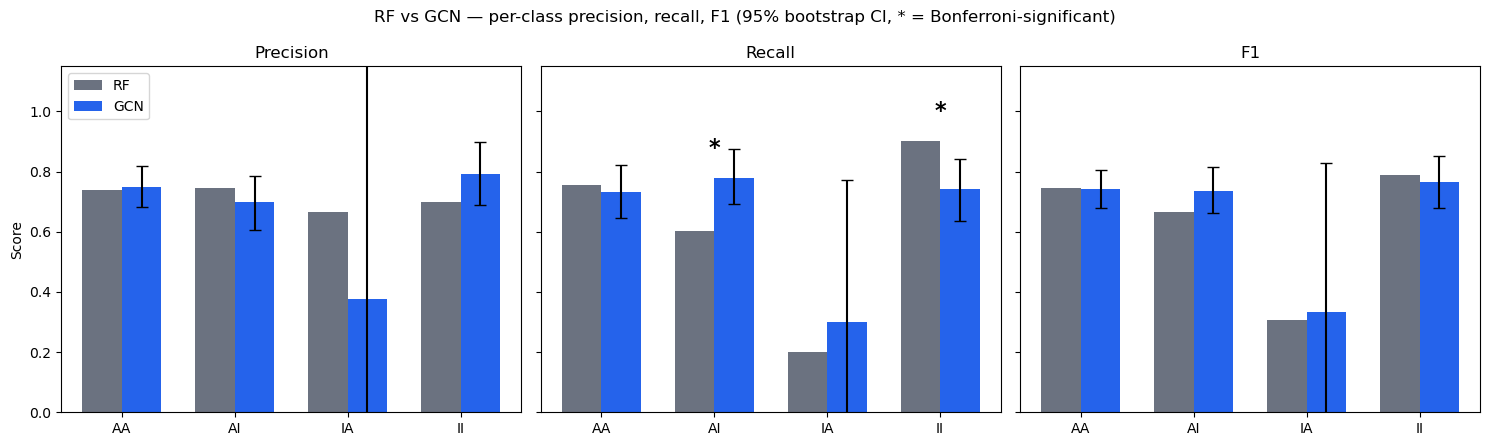

In [79]:
"""
Per-class statistical comparison of RF vs GNN: precision, recall, F1.

Runs ONE combined bootstrap (reusing the same resamples for all three
metrics, rather than three separate bootstrap loops), then produces:
  1. A summary table (pandas DataFrame) with point estimates, 95% CIs,
     and Bonferroni-corrected significance for each metric x class.
  2. A grouped bar chart (RF vs GNN) with 95% CI error bars, one panel
     per metric, saved as a publication-ready PNG.

Requires: numpy, pandas, scikit-learn, matplotlib, (optional) torch
"""
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

try:
    import torch
    HAS_TORCH = True
except ImportError:
    HAS_TORCH = False


def to_numpy(x):
    if HAS_TORCH and isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def bootstrap_full_comparison(y_true, y_pred_rf, y_pred_gnn,
                               class_names=("AA", "AI", "IA", "II"),
                               n_boot=5000, seed=0):
    """
    Single bootstrap loop computing precision, recall, and F1 for both
    models, per class, on the same resamples (so all three metrics are
    directly comparable and computed efficiently in one pass).

    Returns a tidy pandas DataFrame, one row per (class, metric).
    """
    y_true     = to_numpy(y_true)
    y_pred_rf  = to_numpy(y_pred_rf)
    y_pred_gnn = to_numpy(y_pred_gnn)

    rng = np.random.default_rng(seed)
    n = len(y_true)
    n_classes = len(class_names)
    labels = list(range(n_classes))

    metric_fns = {
        "precision": precision_score,
        "recall": recall_score,
        "f1": f1_score,
    }

    # observed (point-estimate) metrics on the full test set
    observed = {
        metric: {
            "rf":  fn(y_true, y_pred_rf,  labels=labels, average=None, zero_division=0),
            "gnn": fn(y_true, y_pred_gnn, labels=labels, average=None, zero_division=0),
        }
        for metric, fn in metric_fns.items()
    }

    # bootstrap: same resample index used across all three metrics
    boot_diffs = {metric: {c: [] for c in range(n_classes)} for metric in metric_fns}

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yt, yrf, ygn = y_true[idx], y_pred_rf[idx], y_pred_gnn[idx]

        for metric, fn in metric_fns.items():
            rf_b  = fn(yt, yrf,  labels=labels, average=None, zero_division=0)
            gnn_b = fn(yt, ygn, labels=labels, average=None, zero_division=0)
            for c in range(n_classes):
                boot_diffs[metric][c].append(gnn_b[c] - rf_b[c])

    # assemble tidy results
    n_per_class = [np.sum(y_true == c) for c in range(n_classes)]
    bonferroni_alpha = 0.05 / n_classes  # per-metric family, corrected across the 4 classes

    rows = []
    for metric in metric_fns:
        for c in range(n_classes):
            diffs = np.array(boot_diffs[metric][c])
            ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
            p_greater = np.mean(diffs <= 0)
            p_less    = np.mean(diffs >= 0)
            p_value = min(2 * min(p_greater, p_less), 1.0)

            rows.append({
                "class": class_names[c],
                "n_true": n_per_class[c],
                "metric": metric,
                "rf": observed[metric]["rf"][c],
                "gnn": observed[metric]["gnn"][c],
                "diff": diffs.mean(),
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": p_value,
                "significant": p_value < bonferroni_alpha,
            })

    df = pd.DataFrame(rows)
    df["bonferroni_alpha"] = bonferroni_alpha
    return df


def print_summary_table(df):
    """Pretty-print one table per metric."""
    for metric in ["precision", "recall", "f1"]:
        sub = df[df["metric"] == metric].copy()
        sub = sub[["class", "n_true", "rf", "gnn", "diff", "ci_low", "ci_high", "p_value", "significant"]]
        sub.columns = ["Class", "n", "RF", "GNN", "Diff (GNN-RF)", "CI low", "CI high", "p-value", "Sig."]
        print(f"\n=== {metric.upper()} ===")
        print(sub.to_string(index=False, float_format=lambda x: f"{x:.3f}"))


def plot_comparison(df, class_order=("AA", "AI", "IA", "II"),
                     save_path=f"{os.getcwd()}/rf_vs_gnn_comparison.png"):
    """Grouped bar chart (RF vs GNN) with 95% CI error bars, one panel per metric."""
    metrics = ["precision", "recall", "f1"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

    x = np.arange(len(class_order))
    width = 0.35

    for ax, metric in zip(axes, metrics):
        sub = df[df["metric"] == metric].set_index("class").loc[list(class_order)]

        rf_vals  = sub["rf"].values
        gnn_vals = sub["gnn"].values

        # error bars for GNN bars reflect the bootstrap CI of the GNN-RF
        # difference, centered on the observed GNN value, for visual
        # reference; the significance stars are the primary signal.
        gnn_err_low  = np.clip(gnn_vals - (rf_vals + sub["ci_low"].values), 0, None)
        gnn_err_high = np.clip((rf_vals + sub["ci_high"].values) - gnn_vals, 0, None)

        ax.bar(x - width/2, rf_vals, width, label="RF", color="#6b7280")
        ax.bar(x + width/2, gnn_vals, width, label="GCN", color="#2563eb",
               yerr=[gnn_err_low, gnn_err_high], capsize=4, ecolor="black")

        for i, sig in enumerate(sub["significant"].values):
            if sig:
                y = max(rf_vals[i], gnn_vals[i]) + 0.06
                ax.text(x[i], y, "*", ha="center", va="bottom", fontsize=16, fontweight="bold")

        ax.set_title(metric.capitalize())
        ax.set_xticks(x)
        ax.set_xticklabels(class_order)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Score" if metric == "precision" else "")

    axes[0].legend(loc="upper left")
    fig.suptitle("RF vs GCN — per-class precision, recall, F1 (95% bootstrap CI, * = Bonferroni-significant)")
    fig.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"\nFigure saved to: {save_path}")
    return fig


if __name__ == "__main__":
    # --- replace with your actual arrays ---
    # y_true, y_pred_rf, y_pred_gcn = ...

    df = bootstrap_full_comparison(y_true, y_pred_rf, y_pred_gcn,
                                    class_names=("AA", "AI", "IA", "II"),
                                    n_boot=5000, seed=0)

    print_summary_table(df)

    # save full tidy results for supplementary material
    df.to_csv(f"{os.getcwd()}/rf_vs_gcn_full_results.csv", index=False)
    print("\nFull results saved")

    plot_comparison(df, save_path=f"{os.getcwd()}/rf_vs_gcn_comparison.png")

## Multi-run evaluation (10 seeds, fixed) — added to correct for run-to-run variability from unfixed GNN initialization.

Each run uses `set_seed(seed)` for `seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]` (python/numpy/torch/cuda RNGs), trains GCN from scratch with early stopping (same protocol as the single-run cells above), and evaluates on the same fixed 226-node test set. Results are aggregated as mean +/- std across the 10 runs.

In [80]:
# ==========================================================================
# Multi-run aggregation helper (mean +/- std across seeds)
# ==========================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, matthews_corrcoef

CLASS_NAMES = ["AA", "AI", "IA", "II"]  # label order: 0=AA, 1=AI, 2=IA, 3=II

def summarize_runs(all_y_true, all_y_pred, all_acc, all_mcc, model_name, out_prefix):
    """
    all_y_true / all_y_pred: lists of numpy arrays, one pair per run (same
        test set each time, so all_y_true[i] should be identical across runs
        -- kept per-run only for safety/verification).
    all_acc / all_mcc: lists of floats, one per run.
    Returns (overall_df, per_class_df) and writes them to CSV.
    """
    n_runs = len(all_acc)

    # ---- per-run classification reports ----
    reports = [
        classification_report(
            yt, yp, labels=list(range(len(CLASS_NAMES))),
            target_names=CLASS_NAMES, output_dict=True, zero_division=0
        )
        for yt, yp in zip(all_y_true, all_y_pred)
    ]

    # ---- overall metrics ----
    overall_df = pd.DataFrame({
        "Metric": ["Accuracy", "MCC"],
        "Mean": [np.mean(all_acc), np.mean(all_mcc)],
        "Std":  [np.std(all_acc),  np.std(all_mcc)],
        "N_runs": [n_runs, n_runs],
    })

    # ---- per-class precision / recall / F1 ----
    rows = []
    for cname in CLASS_NAMES:
        precisions = [r[cname]["precision"] for r in reports]
        recalls    = [r[cname]["recall"]    for r in reports]
        f1s        = [r[cname]["f1-score"]  for r in reports]
        rows.append({
            "Class": cname,
            "Precision_mean": np.mean(precisions), "Precision_std": np.std(precisions),
            "Recall_mean":    np.mean(recalls),    "Recall_std":    np.std(recalls),
            "F1_mean":        np.mean(f1s),        "F1_std":        np.std(f1s),
        })
    per_class_df = pd.DataFrame(rows)

    print(f"\n=== {model_name}: overall performance across {n_runs} runs (mean +/- std) ===")
    print(overall_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    print(f"\n=== {model_name}: per-class performance across {n_runs} runs (mean +/- std) ===")
    print(per_class_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    overall_df.to_csv(f"{out_prefix}_overall_multirun.csv", index=False)
    per_class_df.to_csv(f"{out_prefix}_per_class_multirun.csv", index=False)
    print(f"\nSaved: {out_prefix}_overall_multirun.csv, {out_prefix}_per_class_multirun.csv")

    return overall_df, per_class_df

In [81]:
# ==========================================================================
# GCN: fixed-seed, 10-run training for mean +/- std reporting
# ==========================================================================
SEEDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

all_y_true, all_y_pred, all_acc, all_mcc = [], [], [], []

for run_idx, seed in enumerate(SEEDS):
    set_seed(seed)  # resets python/numpy/torch(+cuda) RNG state for this run

    model = GCN(num_features=train_data.x.size(1), num_classes=int(train_data.y.max()) + 1).to(device)

    criterion = torch.nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

    def train_step(data):
        model.train()
        optimizer.zero_grad()
        out, h = model(data.x, data.edge_index, data.edge_weight)
        loss = criterion(out, data.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        pred = out.argmax(dim=1)
        acc = (pred == data.y).float().mean()
        return loss, acc

    @torch.no_grad()
    def eval_step(data, mask):
        model.eval()
        out, h = model(data.x, data.edge_index, data.edge_weight)
        loss = criterion(out[mask], data.y[mask])
        pred = out[mask].argmax(dim=1)
        acc = (pred == data.y[mask]).float().mean()
        return loss, acc, out

    best_val_acc = 0.0
    patience, trials = 50, 0
    best_state = None
    ckpt_path = f"best_gcn_inductive_multirun_seed{seed}.pt"

    for epoch in range(1, 201):
        loss_train, acc_train = train_step(train_data)
        loss_val, acc_val, _ = eval_step(val_data, val_data.val_mask)

        if acc_val > best_val_acc:
            best_val_acc = acc_val
            trials = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            trials += 1
        if trials >= patience:
            break

    model.load_state_dict(best_state)
    loss_test, acc_test, out_test = eval_step(test_data, test_data.test_mask)

    y_true_run = test_data.y[test_data.test_mask].cpu().numpy()
    y_pred_run = out_test[test_data.test_mask].argmax(dim=1).cpu().numpy()
    mcc_run = matthews_corrcoef(y_true_run, y_pred_run)

    all_y_true.append(y_true_run)
    all_y_pred.append(y_pred_run)
    all_acc.append(acc_test.item())
    all_mcc.append(mcc_run)

    print(f"[GCN] Run {run_idx+1}/10 (seed={seed}): "
          f"Test Acc={acc_test.item():.4f}, MCC={mcc_run:.4f}, "
          f"best epoch val_acc={best_val_acc:.4f}")

overall_gcn, per_class_gcn = summarize_runs(
    all_y_true, all_y_pred, all_acc, all_mcc,
    model_name="GCN", out_prefix="gcn"
)

[GCN] Run 1/10 (seed=0): Test Acc=0.7389, MCC=0.6210, best epoch val_acc=0.7689
[GCN] Run 2/10 (seed=1): Test Acc=0.7301, MCC=0.6061, best epoch val_acc=0.7600
[GCN] Run 3/10 (seed=2): Test Acc=0.7035, MCC=0.5678, best epoch val_acc=0.7600
[GCN] Run 4/10 (seed=3): Test Acc=0.7168, MCC=0.5864, best epoch val_acc=0.7689
[GCN] Run 5/10 (seed=4): Test Acc=0.7257, MCC=0.5997, best epoch val_acc=0.7689
[GCN] Run 6/10 (seed=5): Test Acc=0.7168, MCC=0.5865, best epoch val_acc=0.7778
[GCN] Run 7/10 (seed=6): Test Acc=0.7566, MCC=0.6505, best epoch val_acc=0.7600
[GCN] Run 8/10 (seed=7): Test Acc=0.7478, MCC=0.6336, best epoch val_acc=0.7556
[GCN] Run 9/10 (seed=8): Test Acc=0.7257, MCC=0.6025, best epoch val_acc=0.7644
[GCN] Run 10/10 (seed=9): Test Acc=0.7301, MCC=0.6085, best epoch val_acc=0.7689

=== GCN: overall performance across 10 runs (mean +/- std) ===
  Metric   Mean    Std  N_runs
Accuracy 0.7292 0.0148      10
     MCC 0.6063 0.0229      10

=== GCN: per-class performance across 10 